# Text Emotion Classifier — 7 classes
**Classes:** joy, sadness, anger, disgust, fear, surprise, neutral
**Base model:** `SamLowe/roberta-base-go_emotions` (warm-started encoder)
**Datasets:** GoEmotions + dair-ai/emotion + tweet_eval (emotion config)

## Honest expectations
- Realistic ceiling: **70–78% accuracy, 65–72% macro-F1** on a balanced 7-class held-out set.
- The 95% number on the SamLowe model card is **per-label binary accuracy on a 28-label multi-label task** — not comparable to what we're doing here.
- `disgust` and `neutral` are sourced **only from GoEmotions** (the other two datasets don't have them). Expect weaker recall on these.
- Optimize for **macro-F1 and per-class recall**, not raw accuracy.

## Cell 1 — Install dependencies

In [ ]:
!pip install -q transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 evaluate scikit-learn pandas numpy matplotlib seaborn
# If torch not installed:
# !pip install -q torch --index-url https://download.pytorch.org/whl/cu121

## Cell 2 — Imports and seed

In [2]:
import os, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: NVIDIA GeForce RTX 3060 Ti


## Cell 3 — Define the unified label space

In [3]:
LABELS = ["joy", "sadness", "anger", "disgust", "fear", "surprise", "neutral"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)
print(LABEL2ID)

{'joy': 0, 'sadness': 1, 'anger': 2, 'disgust': 3, 'fear': 4, 'surprise': 5, 'neutral': 6}


## Cell 4 — GoEmotions (28 → 7 mapping)

We use the simplified config and **only keep examples with exactly one label** to avoid forcing a multi-label example into a single class arbitrarily. This costs us some data but keeps labels clean.

In [4]:
GOEMOTIONS_LABELS = [
    'admiration','amusement','anger','annoyance','approval','caring','confusion',
    'curiosity','desire','disappointment','disapproval','disgust','embarrassment',
    'excitement','fear','gratitude','grief','joy','love','nervousness','optimism',
    'pride','realization','relief','remorse','sadness','surprise','neutral'
]

GOEMO_TO_TARGET = {
    # joy bucket
    'admiration':'joy','amusement':'joy','approval':'joy','caring':'joy',
    'desire':'joy','excitement':'joy','gratitude':'joy','joy':'joy',
    'love':'joy','optimism':'joy','pride':'joy','relief':'joy',
    # anger bucket
    'anger':'anger','annoyance':'anger','disapproval':'anger',
    # disgust
    'disgust':'disgust',
    # fear bucket
    'fear':'fear','nervousness':'fear',
    # sadness bucket
    'sadness':'sadness','disappointment':'sadness','embarrassment':'sadness',
    'grief':'sadness','remorse':'sadness',
    # surprise bucket (folds in confusion/curiosity/realization — see note)
    'surprise':'surprise','realization':'surprise','confusion':'surprise','curiosity':'surprise',
    # neutral
    'neutral':'neutral',
}
print("Mapping covers", len(GOEMO_TO_TARGET), "of 28 GoEmotions labels")

Mapping covers 28 of 28 GoEmotions labels


**Design note on `surprise`:** Folding `confusion`, `curiosity`, and `realization` into `surprise` is a known compromise. If your downstream app cares about distinguishing 'surprised' from 'curious', drop these from the mapping (they'll be filtered out) and accept a smaller surprise class.

## Cell 5 — Load and convert GoEmotions

In [7]:
from datasets import load_dataset

go = load_dataset(
    "parquet",
    data_files={
        "train":      "hf://datasets/google-research-datasets/go_emotions/simplified/train-00000-of-00001.parquet",
        "validation": "hf://datasets/google-research-datasets/go_emotions/simplified/validation-00000-of-00001.parquet",
        "test":       "hf://datasets/google-research-datasets/go_emotions/simplified/test-00000-of-00001.parquet",
    }
)
print(go)

go_records = []
for split in ['train', 'validation', 'test']:
    for ex in go[split]:
        labels = ex['labels']
        if len(labels) != 1:
            continue
        name = GOEMOTIONS_LABELS[labels[0]]
        target = GOEMO_TO_TARGET.get(name)
        if target is None:
            continue
        go_records.append({"text": ex['text'], "label": LABEL2ID[target], "source": "goemotions"})

go_df = pd.DataFrame(go_records)
print("GoEmotions single-label, mapped:", len(go_df))
print(go_df['label'].map(ID2LABEL).value_counts())

Generating train split: 43410 examples [00:00, 1489388.27 examples/s]
Generating validation split: 5426 examples [00:00, 1373215.08 examples/s]
Generating test split: 5427 examples [00:00, 1808987.35 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
GoEmotions single-label, mapped: 45446
label
joy         16191
neutral     16021
anger        4883
surprise     4437
sadness      2621
fear          658
disgust       635
Name: count, dtype: int64


## Cell 6 — Load and convert dair-ai/emotion

In [8]:
dair = load_dataset("dair-ai/emotion")
print(dair)

# label ids: 0 sadness, 1 joy, 2 love, 3 anger, 4 fear, 5 surprise
DAIR_LABELS = ['sadness','joy','love','anger','fear','surprise']
DAIR_MAP = {'sadness':'sadness','joy':'joy','love':'joy','anger':'anger','fear':'fear','surprise':'surprise'}

dair_records = []
for split in ['train','validation','test']:
    for ex in dair[split]:
        name = DAIR_LABELS[ex['label']]
        target = DAIR_MAP.get(name)
        if target is None:
            continue
        dair_records.append({"text": ex['text'], "label": LABEL2ID[target], "source": "dair"})

dair_df = pd.DataFrame(dair_records)
print("dair-ai/emotion mapped:", len(dair_df))
print(dair_df['label'].map(ID2LABEL).value_counts())

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
dair-ai/emotion mapped: 20000
label
joy         8402
sadness     5797
anger       2709
fear        2373
surprise     719
Name: count, dtype: int64


## Cell 7 — Load and convert tweet_eval (emotion)

In [9]:
te = load_dataset("tweet_eval", "emotion")
print(te)

# label ids: 0 anger, 1 joy, 2 optimism, 3 sadness
TE_LABELS = ['anger','joy','optimism','sadness']
TE_MAP = {'anger':'anger','joy':'joy','optimism':'joy','sadness':'sadness'}

te_records = []
for split in ['train','validation','test']:
    for ex in te[split]:
        name = TE_LABELS[ex['label']]
        target = TE_MAP.get(name)
        if target is None:
            continue
        te_records.append({"text": ex['text'], "label": LABEL2ID[target], "source": "tweet_eval"})

te_df = pd.DataFrame(te_records)
print("tweet_eval mapped:", len(te_df))
print(te_df['label'].map(ID2LABEL).value_counts())

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
tweet_eval mapped: 5052
label
anger      2118
joy        1608
sadness    1326
Name: count, dtype: int64


## Cell 8 — Combine, dedupe, inspect

Heads-up: `disgust` and `neutral` come **only** from GoEmotions. Watch their counts.

Before dedupe: 70498
After dedupe: 70187

Class distribution (raw combined):
label
joy         25994
neutral     15973
sadness      9732
anger        9695
surprise     5137
fear         3024
disgust       632
Name: count, dtype: int64


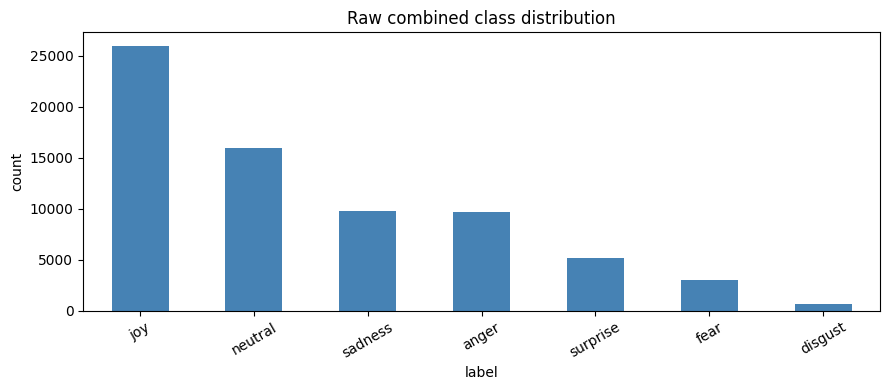

In [10]:
combined = pd.concat([go_df, dair_df, te_df], ignore_index=True)
print("Before dedupe:", len(combined))
combined['text'] = combined['text'].astype(str).str.strip()
combined = combined[combined['text'].str.len() > 0]
combined = combined.drop_duplicates(subset='text').reset_index(drop=True)
print("After dedupe:", len(combined))

print("\nClass distribution (raw combined):")
dist = combined['label'].value_counts().rename(index=ID2LABEL)
print(dist)

plt.figure(figsize=(9,4))
dist.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title("Raw combined class distribution")
plt.ylabel("count"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Cell 9 — Balance the dataset

Cap dominant classes at `TARGET_MAX`, oversample tiny classes up to `TARGET_MIN` (with replacement). Oversampling alone causes overfitting on minority classes — that's why we also use class weights in the loss (Cell 14). Belt + suspenders.

In [11]:
TARGET_MIN = 4000
TARGET_MAX = 12000

balanced_parts = []
for label_id, group in combined.groupby('label'):
    n = len(group)
    if n > TARGET_MAX:
        sub = group.sample(TARGET_MAX, random_state=SEED)
    elif n < TARGET_MIN:
        extra = group.sample(TARGET_MIN - n, replace=True, random_state=SEED)
        sub = pd.concat([group, extra])
    else:
        sub = group
    balanced_parts.append(sub)

balanced = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
print("Balanced size:", len(balanced))
print(balanced['label'].value_counts().rename(index=ID2LABEL))

Balanced size: 56564
label
joy         12000
neutral     12000
sadness      9732
anger        9695
surprise     5137
fear         4000
disgust      4000
Name: count, dtype: int64


## Cell 10 — Stratified train/val/test split (80/10/10)

In [12]:
train_df, temp_df = train_test_split(
    balanced, test_size=0.2, stratify=balanced['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)
print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
print("\nTrain class distribution:")
print(train_df['label'].value_counts().rename(index=ID2LABEL).sort_index())

train: 45251 val: 5656 test: 5657

Train class distribution:
label
anger       7756
disgust     3200
fear        3200
joy         9600
neutral     9600
sadness     7785
surprise    4110
Name: count, dtype: int64


## Cell 11 — Tokenize

In [13]:
MODEL_NAME = "SamLowe/roberta-base-go_emotions"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf(df):
    ds = Dataset.from_pandas(df[['text','label']].reset_index(drop=True))
    ds = ds.map(
        lambda x: tokenizer(x['text'], truncation=True, max_length=128),
        batched=True,
        remove_columns=['text']
    )
    return ds

train_ds = to_hf(train_df)
val_ds   = to_hf(val_df)
test_ds  = to_hf(test_df)
print(train_ds)

Map: 100%|██████████| 5657/5657 [00:00<00:00, 70934.33 examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 45251
})


## Cell 12 — Load model with a fresh 7-class head

Base model has 28 output classes. We replace the classification head — `ignore_mismatched_sizes=True`. Encoder weights kept (warm start), head randomly initialized for our 7 classes.

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
print(model.config.num_labels, "labels — head replaced.")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at SamLowe/roberta-base-go_emotions and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([28]) in the checkpoint and torch.Size([7]) in the model instantiated
- classifier.out_proj.weight: found shape torch.Size([28, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


7 labels — head replaced.


## Cell 13 — Compute class weights

In [15]:
y_train = np.array(train_df['label'])
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=y_train,
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float)
print("Class weights:")
for i, w in enumerate(class_weights_np):
    print(f"  {ID2LABEL[i]:<10} {w:.3f}")

Class weights:
  joy        0.673
  sadness    0.830
  anger      0.833
  disgust    2.020
  fear       2.020
  surprise   1.573
  neutral    0.673


## Cell 14 — Weighted-loss Trainer + metrics

In [16]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device),
            label_smoothing=0.05,
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':    accuracy_score(labels, preds),
        'macro_f1':    f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
    }

## Cell 15 — Training arguments

Defaults tuned for one mid-range GPU (T4/A10/3090). On A100 push batch size to 64 and `num_train_epochs=4`. On CPU — don't.

In [17]:
args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

## Cell 16 — Train

In [18]:
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(train_result)

  1%|▏         | 102/7075 [00:10<12:28,  9.31it/s]

{'loss': 1.9055, 'grad_norm': 4.883172035217285, 'learning_rate': 2.8248587570621473e-06, 'epoch': 0.07}


  3%|▎         | 202/7075 [00:21<12:09,  9.42it/s]

{'loss': 1.6305, 'grad_norm': 5.888138294219971, 'learning_rate': 5.6497175141242946e-06, 'epoch': 0.14}


  4%|▍         | 302/7075 [00:32<11:17, 10.00it/s]

...

{'loss': 0.4852, 'grad_norm': 13.75023078918457, 'learning_rate': 2.5129574367834146e-07, 'epoch': 4.95}


                                                   
100%|██████████| 7075/7075 [13:43<00:00,  9.08it/s]

{'eval_loss': 0.7035601735115051, 'eval_accuracy': 0.83504243281471, 'eval_macro_f1': 0.8415375258255294, 'eval_weighted_f1': 0.8337518547406761, 'eval_runtime': 6.6054, 'eval_samples_per_second': 856.27, 'eval_steps_per_second': 13.474, 'epoch': 5.0}


100%|██████████| 7075/7075 [13:45<00:00,  8.57it/s]

{'train_runtime': 825.169, 'train_samples_per_second': 274.192, 'train_steps_per_second': 8.574, 'train_loss': 0.650999759094454, 'epoch': 5.0}
TrainOutput(global_step=7075, training_loss=0.650999759094454, metrics={'train_runtime': 825.169, 'train_samples_per_second': 274.192, 'train_steps_per_second': 8.574, 'total_flos': 5166683703810300.0, 'train_loss': 0.650999759094454, 'epoch': 5.0})


## Cell 17 — Evaluate on the held-out test set

**Read the per-class report.** High `accuracy` with low `disgust`/`fear` recall means the model is cheating by predicting majority classes. That fails in production.

In [19]:
preds_out = trainer.predict(test_ds)
y_pred = np.argmax(preds_out.predictions, axis=-1)
y_true = preds_out.label_ids

print("Test accuracy:    ", accuracy_score(y_true, y_pred))
print("Test macro-F1:    ", f1_score(y_true, y_pred, average='macro'))
print("Test weighted-F1: ", f1_score(y_true, y_pred, average='weighted'))
print()
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

100%|██████████| 89/89 [00:06<00:00, 13.73it/s]

Test accuracy:     0.838253491249779
Test macro-F1:     0.8473836307198769
Test weighted-F1:  0.836476728234926

              precision    recall  f1-score   support

         joy     0.8512    0.8867    0.8686      1200
     sadness     0.8837    0.8819    0.8828       974
       anger     0.7976    0.8247    0.8109       970
     disgust     0.9186    0.9875    0.9518       400
        fear     0.8497    0.9750    0.9080       400
    surprise     0.7243    0.7680    0.7455       513
     neutral     0.8408    0.7000    0.7640      1200

    accuracy                         0.8383      5657
   macro avg     0.8380    0.8606    0.8474      5657
weighted avg     0.8386    0.8383    0.8365      5657



## Cell 18 — Confusion matrix

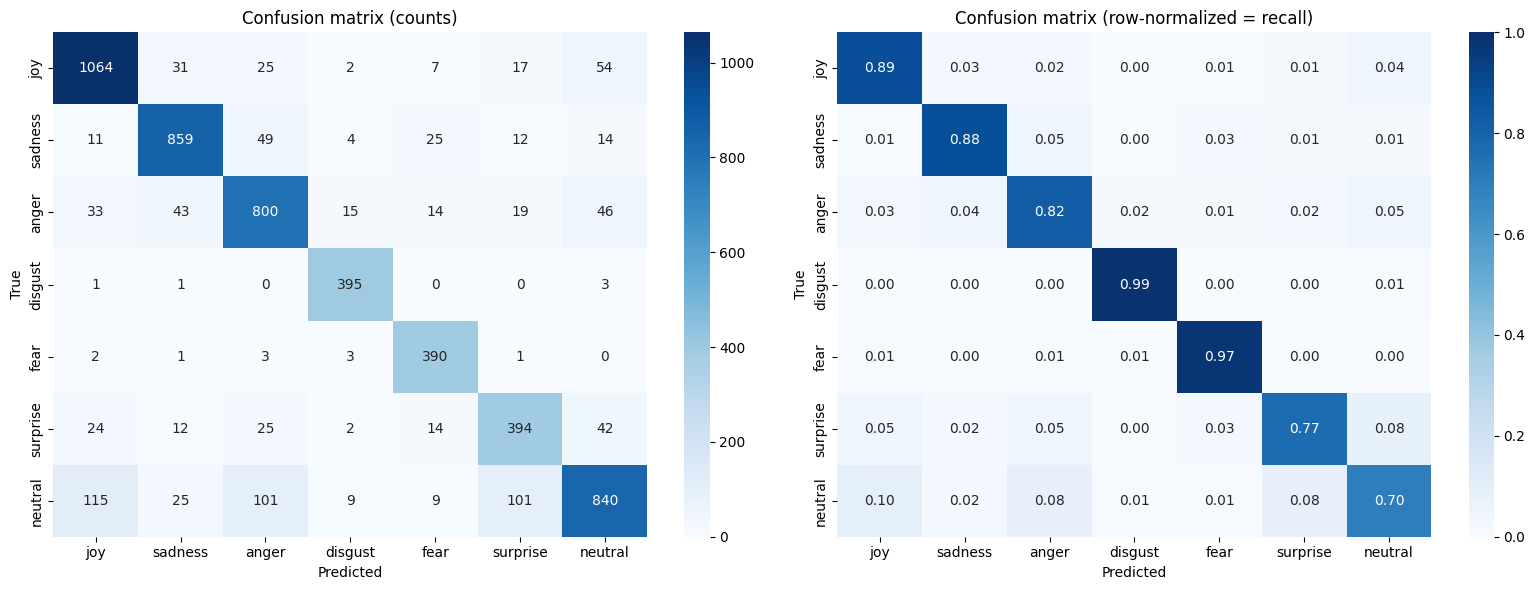

In [20]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS,
            cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion matrix (counts)"); axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=LABELS, yticklabels=LABELS,
            cmap='Blues', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Confusion matrix (row-normalized = recall)"); axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
plt.tight_layout(); plt.show()

## Cell 19 — Save the final model

In [21]:
SAVE_DIR = "./emotion_text_final"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(f"{SAVE_DIR}/labels.json", "w") as f:
    json.dump({"id2label": ID2LABEL, "label2id": LABEL2ID, "labels": LABELS}, f, indent=2)
print("Saved to", SAVE_DIR)

Saved to ./emotion_text_final


In [22]:
import torch

# Save
torch.save({
    "model_state_dict": model.state_dict(),
    "label2id": LABEL2ID,
    "id2label": ID2LABEL
}, "emotion_model.pt")

print("Saved as emotion_model.pt")

Saved as emotion_model.pt


In [23]:
checkpoint = torch.load("emotion_model.pt")

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## Cell 20 — Inference helper for your webapp backend

In [24]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    top_k=None,
    device=0 if torch.cuda.is_available() else -1,
)

def predict_emotion(text: str):
    """Returns list of {label, score} sorted by score desc."""
    out = clf(text, truncation=True, max_length=128)[0]
    return sorted(out, key=lambda x: -x['score'])

samples = [
    "I just got promoted, I can't believe it!",
    "I miss them so much it hurts.",
    "Why would you do that, that's revolting.",
    "I'm not sure I can do this, my hands are shaking.",
    "Oh wow, I did NOT expect that.",
    "It's fine. The meeting is at 3pm.",
    "I can't stand this anymore, I'm done.",
]
for s in samples:
    top = predict_emotion(s)[0]
    print(f"[{top['label']:<8} {top['score']:.2f}]  {s}")

[surprise 0.96]  I just got promoted, I can't believe it!
[sadness  0.98]  I miss them so much it hurts.
[anger    0.97]  Why would you do that, that's revolting.
[fear     0.98]  I'm not sure I can do this, my hands are shaking.
[surprise 0.99]  Oh wow, I did NOT expect that.
[neutral  0.95]  It's fine. The meeting is at 3pm.
[anger    0.98]  I can't stand this anymore, I'm done.


In [31]:
from transformers import pipeline
import torch

clf = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    top_k=None,
    device=0 if torch.cuda.is_available() else -1,
)

def predict_emotion(text: str):
    out = clf(text, truncation=True, max_length=128)[0]
    return sorted(out, key=lambda x: -x['score'])


# 👉 Add ground truth labels here
samples = [
    ("Even after everything that happened, seeing her smile again filled me with warmth I can't describe.", "joy"),
    ("I thought time would heal it, but the emptiness just keeps growing day by day.", "sadness"),
    ("The way they ignored all my efforts as if they meant nothing makes me furious.", "anger"),
    ("My heart was racing as I walked into the room, unsure of what was about to happen.", "fear"),
    ("I genuinely didn't expect things to turn out this way, it completely caught me off guard.", "surprise"),
    ("The smell and the mess in that place made me feel sick to my stomach instantly.", "disgust"),
    ("We reviewed the report and scheduled the next meeting for Monday morning.", "neutral"),
]

print(f"{'TRUE':<10} {'PREDICTED':<10} {'SCORE':<6} TEXT")
print("-"*60)

for text, true_label in samples:
    preds = predict_emotion(text)
    top = preds[0]

    #print(f"{true_label:<10} {top['label']:<10} {top['score']:.2f}  {text}")
    correct = "✔" if top['label'] == true_label else "❌"
    print(f"{correct} {true_label:<10} {top['label']:<10} {top['score']:.2f}  {text}")

TRUE       PREDICTED  SCORE  TEXT
------------------------------------------------------------
✔ joy        joy        0.97  Even after everything that happened, seeing her smile again filled me with warmth I can't describe.
✔ sadness    sadness    0.97  I thought time would heal it, but the emptiness just keeps growing day by day.
✔ anger      anger      0.98  The way they ignored all my efforts as if they meant nothing makes me furious.
✔ fear       fear       0.99  My heart was racing as I walked into the room, unsure of what was about to happen.
✔ surprise   surprise   0.99  I genuinely didn't expect things to turn out this way, it completely caught me off guard.
❌ disgust    anger      0.91  The smell and the mess in that place made me feel sick to my stomach instantly.
✔ neutral    neutral    0.98  We reviewed the report and scheduled the next meeting for Monday morning.


## Cell 21 — Error analysis (do not skip)

The single most useful thing before declaring victory: look at what the model gets wrong.
1. Label noise in source datasets (a 'fear' example that's clearly anger)
2. Domain artifacts (Twitter `@user`, Reddit edits)
3. Genuinely ambiguous examples no model will get right

Categories 1 and 2 → better data cleaning. Category 3 is your real ceiling.

In [32]:
mistakes = pd.DataFrame({
    'text': test_df['text'].values,
    'true': [ID2LABEL[i] for i in y_true],
    'pred': [ID2LABEL[i] for i in y_pred],
    'confidence': preds_out.predictions.max(axis=1),
})
mistakes = mistakes[mistakes['true'] != mistakes['pred']]
print(f"{len(mistakes)} mistakes out of {len(y_true)} ({len(mistakes)/len(y_true):.1%})")

print("\n--- 20 most confident mistakes ---")
print(mistakes.nlargest(20, 'confidence').to_string(index=False))

915 mistakes out of 5657 (16.2%)

--- 20 most confident mistakes ---
                                                                                                                                       text     true     pred  confidence
                                                                                             honestly, individually he's been awful so far.    anger  disgust    5.160156
                                                       Cold sores are the worst. The second you smile or laugh, it's over. Blood everywhere  sadness  disgust    5.089844
                                                                               That was such awful bandaid application. Like what the fuck.    anger  disgust    5.070312
                                                     This is awful and borderline abuse. I can't imagine thinking that's even slightly okay  sadness  disgust    5.007812
                           Even this tweet reeks just from the description provid

## Cell 22 — Where to push next if you want more accuracy

Rough order of expected payoff:

1. **Use GoEmotions multi-label rows** — currently dropped. Pick dominant via heuristic, or train multi-label and threshold at inference.
2. **Add MELD / EmoryNLP** — conversational dialogue datasets, closer to real chat input than Reddit comments.
3. **Two-stage classifier** — first predict positive/negative/neutral (~90%), then fine-grained within each polarity.
4. **`roberta-large` or `deberta-v3-large`** — +2–4% accuracy, ~3x slower. Only after data is clean.
5. **Active learning** — surface high-confidence label disagreements, hand-correct worst 1000. Often more impactful than architecture changes.

What will **not** get you to 95%:
- Bigger models alone
- More epochs (overfit)
- More data from same noisy sources

Move to voice/video only after the text confusion matrix looks clean. At fusion time, text is usually the strongest signal — a noisy text branch drags everything down.